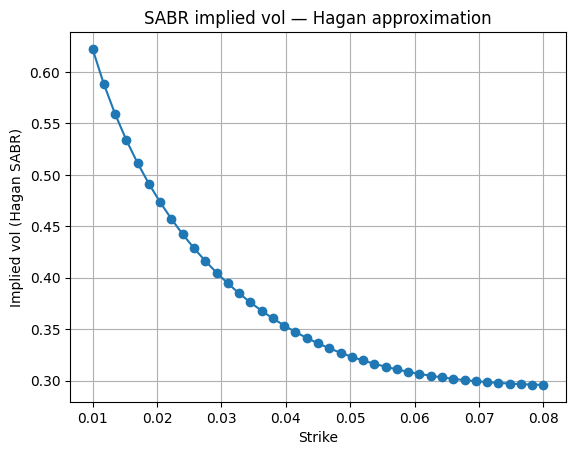

In [5]:
"""
Hagan et al. (2002) SABR implied volatility approximation (Python).

This module provides the classic Hagan analytic approximation that maps SABR
parameters (alpha, beta, rho, nu) to a Black-Scholes implied volatility.

Usage:
sigma_imp = hagan_implied_vol(F, K, T, alpha, beta, rho, nu)

Parameters (notation):
F     : forward price (can be scalar or numpy array)
K     : strike price (same shape as F or broadcastable)
T     : time to expiry (scalar)
alpha : initial volatility parameter (often called "alpha" in Hagan)
beta  : SABR beta (0 <= beta <= 1)
rho   : correlation between the Brownian motions ([-1,1])
nu    : vol-of-vol (often denoted "nu")

Notes:

* This implementation handles the ATM (F ~= K) limit safely.
* Vectorized: F and K can be numpy arrays; function returns array of implied vols.
* For extremely small log(F/K) the ATM formula (limit) is used to avoid numerical instability.
  """

import numpy as np

def _x_of_z(z, rho):
    """Compute x(z) = ln( (sqrt(1 - 2 rho z + z^2) + z - rho) / (1 - rho) )"""
    # Protect against small negative rounding beyond domain by clipping inside sqrt.
    inside = 1.0 - 2.0 * rho * z + z * z
    # Numerical safety
    inside = np.maximum(inside, 0.0)
    return np.log((np.sqrt(inside) + z - rho) / (1.0 - rho))

def hagan_implied_vol(F, K, T, alpha, beta, rho, nu):
    """
    Hagan SABR implied volatility approximation.
    
    ```
    Returns Black-Scholes implied volatility corresponding to SABR params.
    
    Parameters:
        F, K : float or array_like
        T    : float (time to maturity)
        alpha: float (SABR alpha, initial volatility level)
        beta : float in [0,1]
        rho  : float in [-1,1]
        nu   : float (vol-of-vol)
    
    Returns:
        sigma_imp: implied volatility (same shape as broadcast(F, K))
    """
    F = np.array(F, dtype=float)
    K = np.array(K, dtype=float)
    # broadcast shapes
    FK = F * K
    # avoid division by zero
    logFK = np.log(F / K)
    abs_log = np.abs(logFK)
    
    # Common factors
    one_minus_beta = 1.0 - beta
    # Denominator D for the prefactor (Hagan equation)
    # D = (F*K)^{(1-beta)/2} * [1 + (1-beta)^2/24 * ln(F/K)^2 + (1-beta)^4/1920 * ln(F/K)^4]
    with np.errstate(divide='ignore'):
        FK_pow = np.power(FK, one_minus_beta / 2.0)
    # When F or K is zero, handle carefully (but SABR's domain usually F,K>0)
    FK_pow = np.where(FK <= 0, 0.0, FK_pow)
    logFK2 = logFK * logFK
    logFK4 = logFK2 * logFK2
    denom_correction = 1.0 + (one_minus_beta**2 / 24.0) * logFK2 + (one_minus_beta**4 / 1920.0) * logFK4
    D = FK_pow * denom_correction
    
    # z and x(z)
    # Avoid division by zero when alpha == 0
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (nu / alpha) * FK_pow * logFK  # note FK_pow = (F*K)^{(1-beta)/2}
    # compute x(z)
    x_z = _x_of_z(z, rho)
    
    # prefactor A
    # For numerical safety, when D==0 (e.g., FK==0) use alternative handling (set A large or NaN)
    A = np.where(D > 0, alpha / D, np.nan)
    
    # z/x(z) term; handle z==0 via limit: z/x(z) -> 1 as z->0
    small_z = np.abs(z) < 1e-12
    zx = np.empty_like(z)
    zx[small_z] = 1.0  # use limit
    zx[~small_z] = z[~small_z] / x_z[~small_z]
    
    # C term (1 + ... * T)
    # c1 = ( (1-beta)^2 / 24 ) * (alpha^2 / (F*K)^{1-beta} )
    # c2 = rho * beta * nu * alpha / (4 * (F*K)^{(1-beta)/2})
    # c3 = (2 - 3 rho^2) * nu^2 / 24
    with np.errstate(divide='ignore', invalid='ignore'):
        FK_1mb = np.power(FK, one_minus_beta)  # (F*K)^{1-beta}
        FK_half = np.power(FK, one_minus_beta / 2.0)  # (F*K)^{(1-beta)/2}
    # protect against zero FK
    FK_1mb = np.where(FK_1mb <= 0, np.nan, FK_1mb)
    FK_half = np.where(FK_half <= 0, np.nan, FK_half)
    
    c1 = (one_minus_beta**2 / 24.0) * (alpha**2 / FK_1mb)
    c2 = (rho * beta * nu * alpha) / (4.0 * FK_half)
    c3 = ((2.0 - 3.0 * rho**2) * (nu**2)) / 24.0
    C = 1.0 + (c1 + c2 + c3) * T
    
    # full sigma for non-ATM (F != K)
    sigma = A * zx * C
    
    # ATM case (use limit as K->F)
    # ATM formula:
    # sigma_ATM = alpha / F^{1-beta} * [ 1 + ( ((1-beta)^2/24) * (alpha^2 / F^{2-2beta}) + (rho*beta*nu*alpha)/(4*F^{1-beta}) + ((2-3 rho^2)*nu^2/24) ) * T ]
    with np.errstate(divide='ignore', invalid='ignore'):
        F_pow = np.power(F, one_minus_beta)
        F_pow2 = np.power(F, 2.0 * one_minus_beta)
    atm_pref = np.where(F > 0, alpha / F_pow, np.nan)
    atm_c1 = (one_minus_beta**2 / 24.0) * (alpha**2 / F_pow2)
    atm_c2 = (rho * beta * nu * alpha) / (4.0 * F_pow)
    atm_c3 = ((2.0 - 3.0 * rho**2) * nu**2) / 24.0
    sigma_atm = atm_pref * (1.0 + (atm_c1 + atm_c2 + atm_c3) * T)
    
    # Choose ATM where |logFK| is very small
    sigma = np.where(abs_log < 1e-8, sigma_atm, sigma)
    
    # Final safety: ensure non-negative
    sigma = np.maximum(sigma, 0.0)
    return sigma


# Example usage

# if **name** == "**main**":
import matplotlib.pyplot as plt
F0 = 0.04
alpha = 0.07   # initial vol level (Hagan's alpha)
beta = 0.5
rho = -0.3
nu = 0.4       # vol-of-vol
T = 1.0


strikes = np.linspace(0.01, 0.08, 41)
vols = hagan_implied_vol(F0, strikes, T, alpha, beta, rho, nu)

plt.plot(strikes, vols, marker='o')
plt.xlabel("Strike")
plt.ylabel("Implied vol (Hagan SABR)")
plt.title("SABR implied vol — Hagan approximation")
plt.grid(True)
plt.show()

